In [2]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [4]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [5]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [6]:
negative_feedback_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "convex_double_sae_ref_v3"
non_naive_f_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "non_naive_f_v3"
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"
p_var_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "p_var_v3"

In [7]:
negative_feedback_recalls, negative_feedback_precisions = get_precisions_recalls(negative_feedback_path)
non_naive_f_recalls, non_naive_f_precisions = get_precisions_recalls(non_naive_f_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
p_var_recalls, p_var_precisions = get_precisions_recalls(p_var_path)
# imp_s_recalls, imp_s_precisions = get_precisions_recalls(imp_s_path)

In [8]:
negative_feedback_recalls_auc = get_recalls_auc(negative_feedback_path)
non_naive_f_recalls_auc = get_recalls_auc(non_naive_f_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)
p_var_recalls_auc = get_recalls_auc(p_var_path)
# imp_s_recalls_auc = get_recalls_auc(imp_s_path)

In [9]:
np.array(negative_feedback_recalls_auc).mean(), np.array(baseline_recalls_auc).mean(), np.array(non_naive_f_recalls_auc).mean()

(np.float64(0.9055712813622774),
 np.float64(0.8937074946193079),
 np.float64(0.900677103301394))

In [10]:
np.array(p_var_recalls_auc).mean()

np.float64(0.9041793973335168)

In [11]:
np.array(negative_feedback_recalls_auc).mean() - np.array(non_naive_f_recalls_auc).mean()

np.float64(0.004894178060883325)

In [12]:
np.array(baseline_recalls_auc).mean() - np.array(non_naive_f_recalls_auc).mean()

np.float64(-0.006969608682086181)

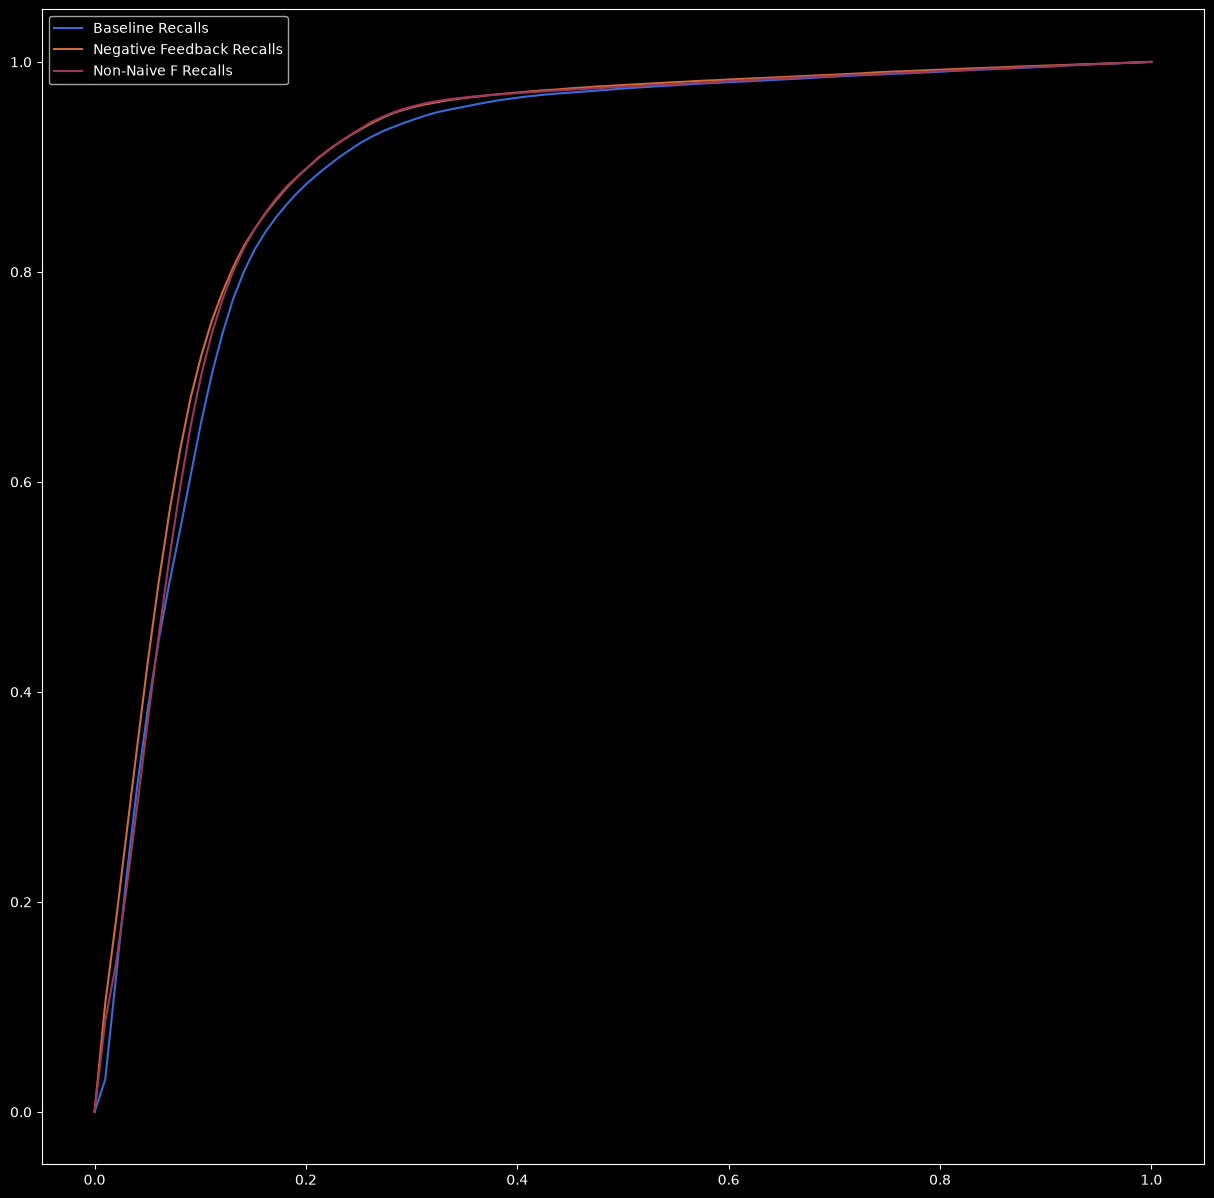

In [13]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(negative_feedback_recalls).mean(axis=0),
         label="Negative Feedback Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls).mean(axis=0),
         label="Non-Naive F Recalls")
# plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_var_recalls).mean(axis=0),
#          label="P Var Recalls")


plt.legend()

In [14]:
len(negative_feedback_recalls)

30

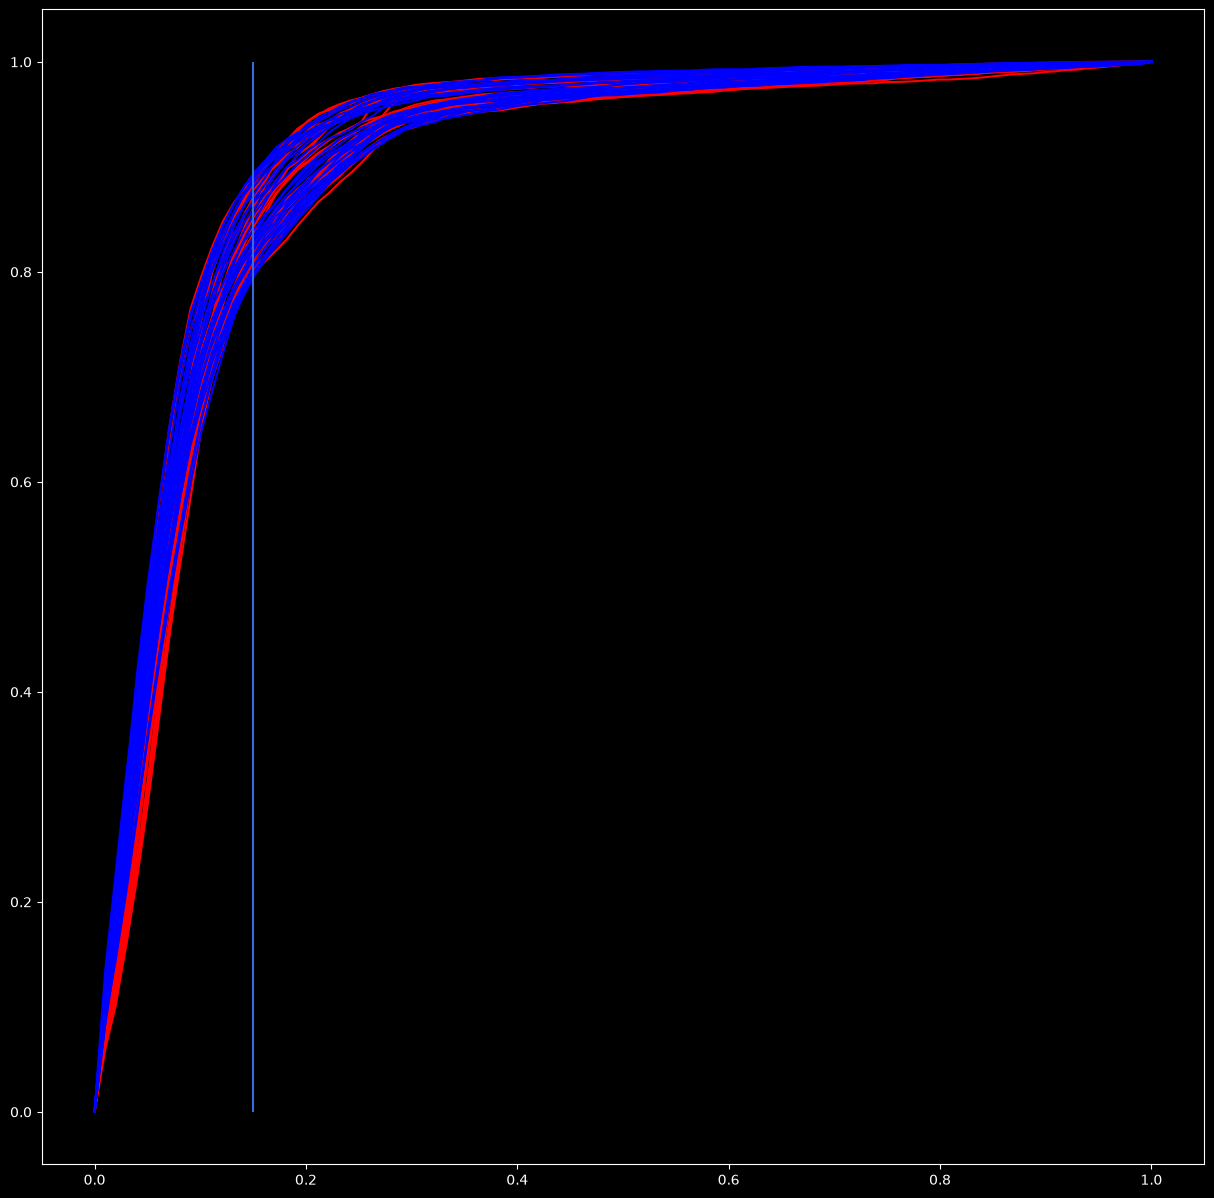

In [15]:
plt.figure(figsize=(15, 15))

for i in range(len(non_naive_f_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls)[i],
         label="P Not Sent Recalls", color = "red")

for i in range(len(negative_feedback_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(negative_feedback_recalls)[i],
         label="P Not Sent Recalls", color="blue")


# for i in range(30):
#     plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
#          label="P Not Sent Recalls", color = "green")

plt.vlines(x=0.15, ymin=0, ymax=1)

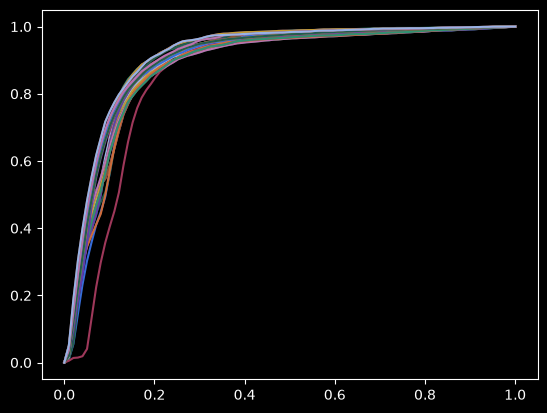

In [16]:
for i in range(30):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="P Not Sent Recalls")

In [17]:
sae_experiments: list[list] = load_experiment_metrics(negative_feedback_path)

In [18]:
sae_s = []

for experiment in sae_experiments:
    sae_s += [metric.prediction for metric in experiment]

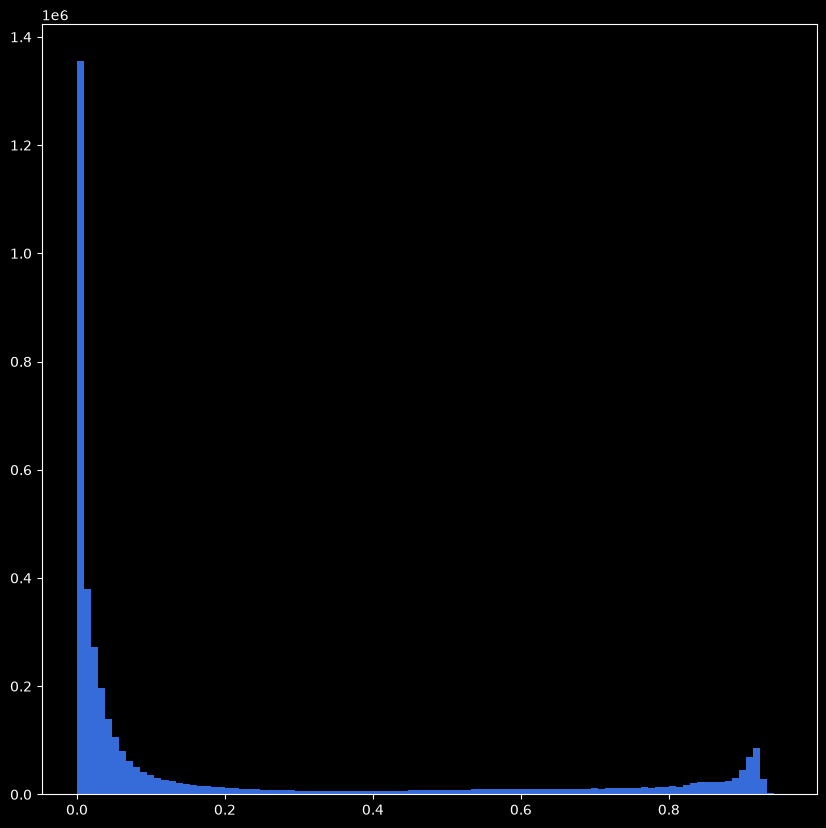

In [19]:
plt.figure(figsize=(10, 10))

plt.hist(sae_s, bins=100)
plt.show()

In [20]:
delta_pct(
    np.array(negative_feedback_recalls).mean(axis=0),
    np.array(non_naive_f_recalls).mean(axis=0),

)

array([ 0.  ,  1.71,  4.09,  5.23,  5.67,  5.63,  5.14,  4.36,  3.63,
        2.7 ,  1.85,  1.19,  0.7 ,  0.35,  0.2 ,  0.03, -0.07, -0.15,
       -0.12, -0.04, -0.01,  0.07,  0.02,  0.01, -0.04, -0.08, -0.13,
       -0.09, -0.06, -0.09, -0.09, -0.1 , -0.11, -0.08, -0.07, -0.05,
       -0.04, -0.  ,  0.04,  0.05,  0.05,  0.08,  0.1 ,  0.09,  0.11,
        0.13,  0.14,  0.16,  0.15,  0.16,  0.17,  0.17,  0.17,  0.16,
        0.18,  0.17,  0.18,  0.19,  0.16,  0.16,  0.15,  0.15,  0.14,
        0.13,  0.12,  0.12,  0.12,  0.12,  0.12,  0.12,  0.12,  0.12,
        0.13,  0.16,  0.16,  0.15,  0.14,  0.14,  0.14,  0.14,  0.13,
        0.13,  0.13,  0.12,  0.1 ,  0.1 ,  0.1 ,  0.09,  0.08,  0.07,
        0.06,  0.04,  0.05,  0.04,  0.02,  0.02,  0.02,  0.  ,  0.  ,
        0.  ])